In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


/tmp/ipython-input-2393579168.py:72: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/Shareddrives/ACCESS_project/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5')


(15736, 10) (15736, 1)
<class 'numpy.ndarray'>


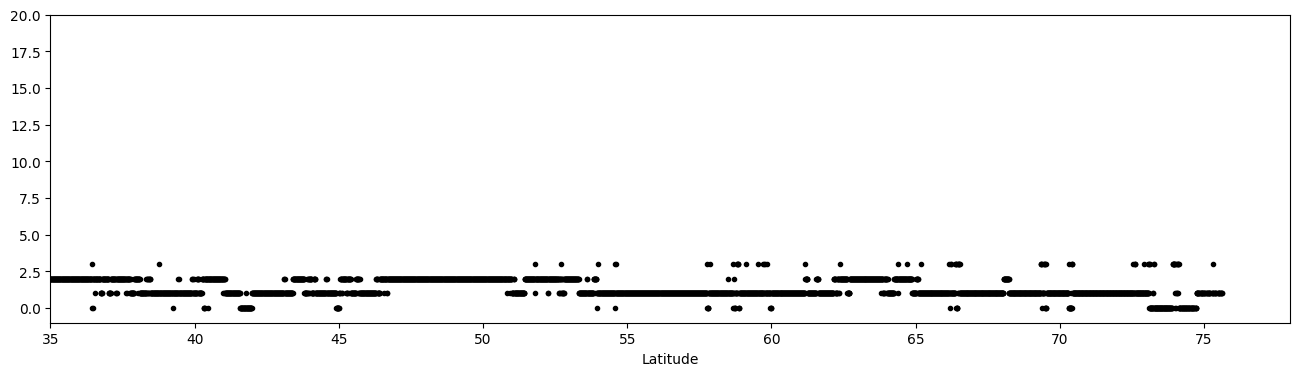

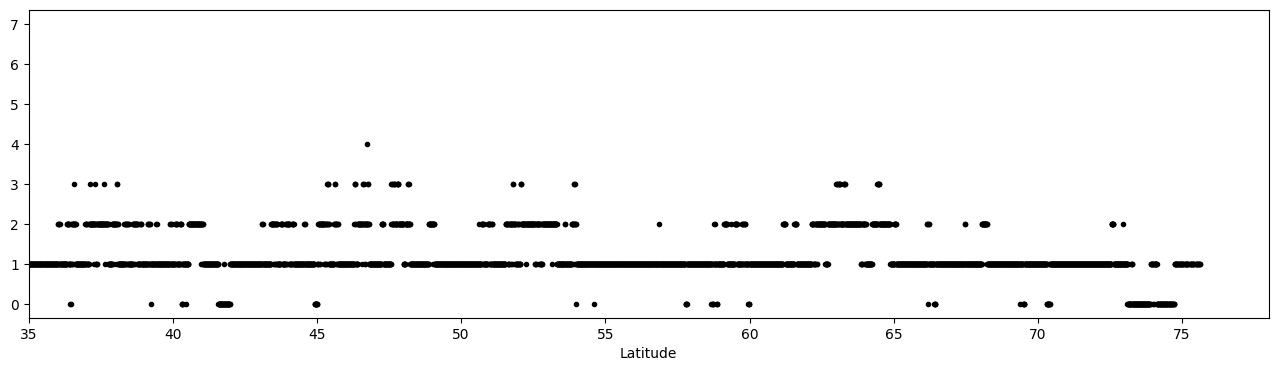

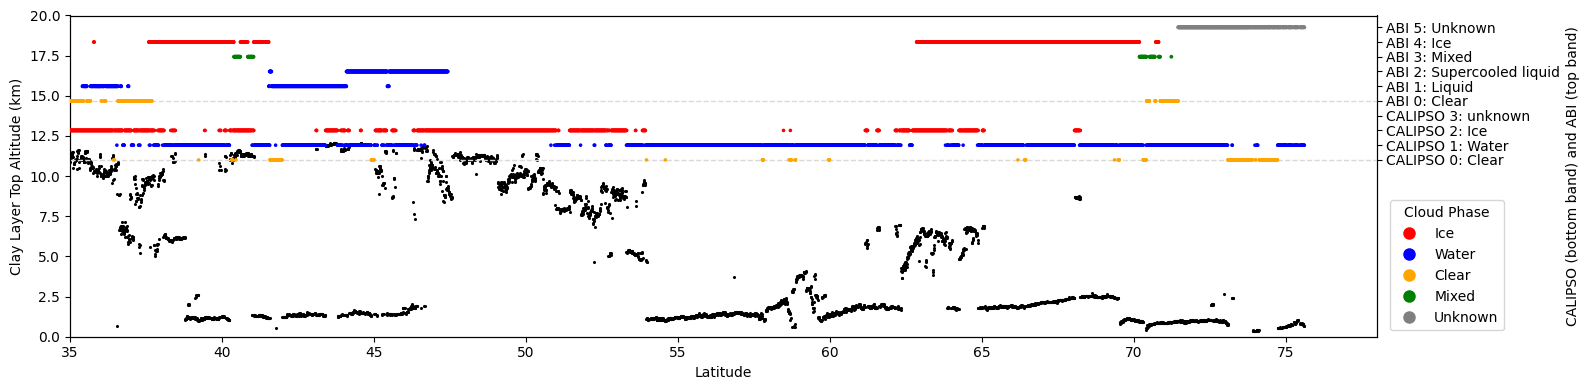

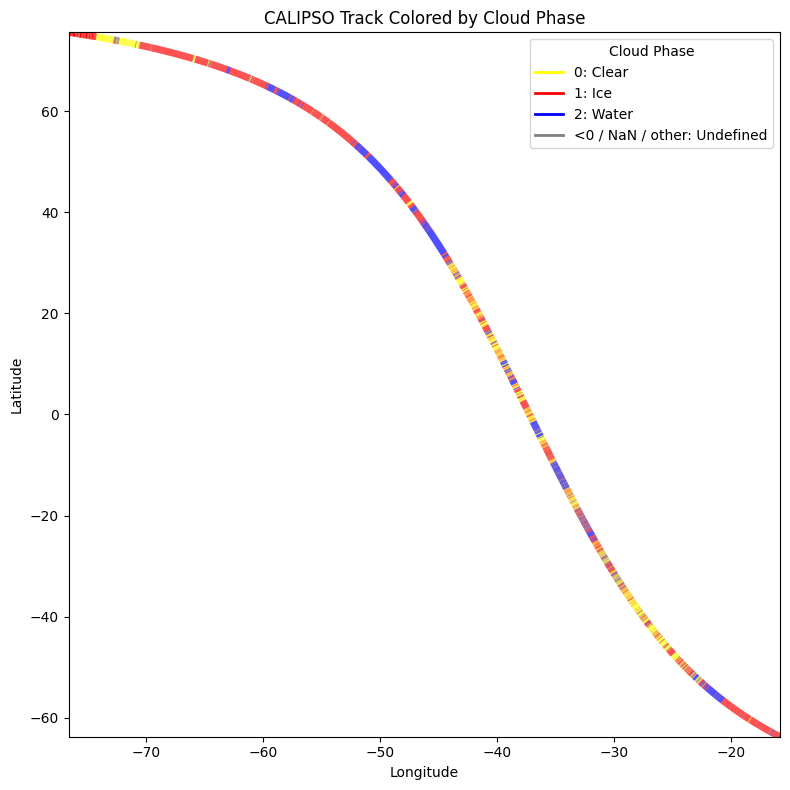

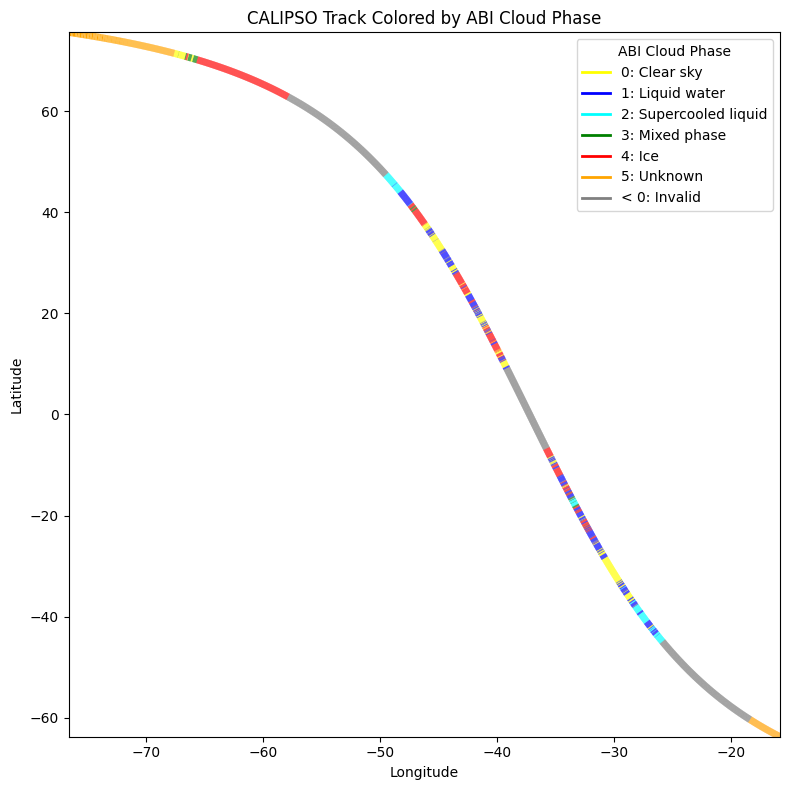

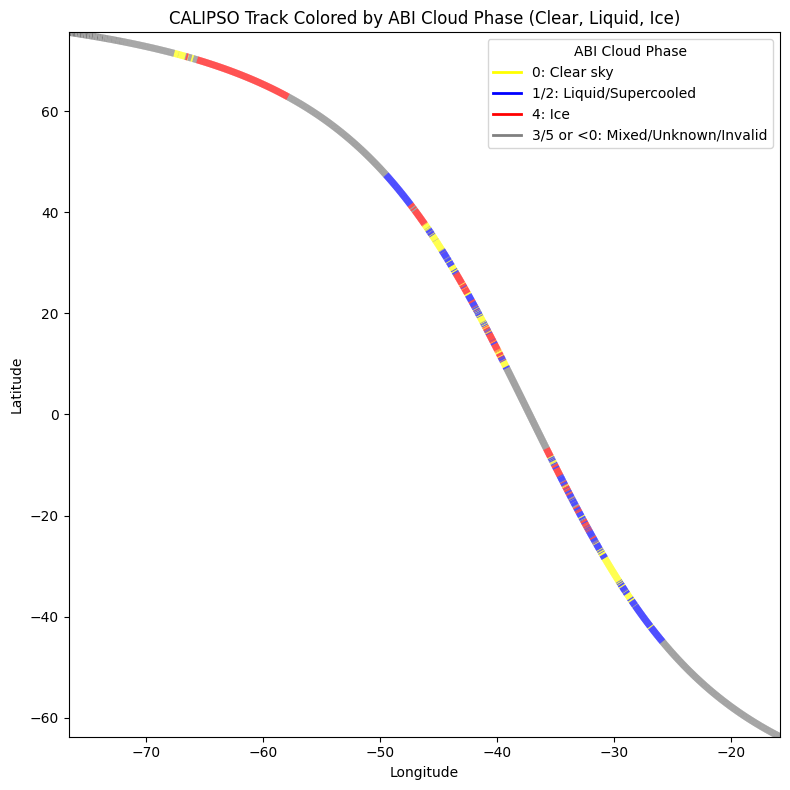

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


#df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T14-03-59ZD.h5')
df = xr.open_dataset('/content/drive/Shareddrives/ACCESS_project/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape

#---- added by zhibo-------
new_ice_water_phase = np.full_like(ice_water_phase[:,0],-1)
new_ice_water_phase[np.logical_or(ice_water_phase[:,0]==1, ice_water_phase[:,0]==3)] = 2
new_ice_water_phase[ice_water_phase[:,0]==2] = 1
new_ice_water_phase[ice_water_phase[:,0]==65535] = 0
new_ice_water_phase[ice_water_phase[:,0]==0] = 3



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,new_ice_water_phase,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(new_ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(new_ice_water_phase) #.ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: WAT, 2: ICE, 3:UNK}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Water", 2: "CALIPSO 2: Ice",3: "CALIPSO 3: unknown"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2,3]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2,3]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = new_ice_water_phase #ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
ls /content/drive/Shareddrives/ACCESS_project/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5

/content/drive/Shareddrives/ACCESS_project/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)

#



=== CALIPSO feature_type ===
Total considered: 13,268 | Unique values: 2
value   2:     10,501  ( 79.15%)
value 65535:      2,767  ( 20.85%)

=== CALIPSO ice_water_phase ===
Total considered: 13,268 | Unique values: 5
value   0:        224  (  1.69%)
value   1:      4,614  ( 34.78%)
value   2:      5,655  ( 42.62%)
value   3:          8  (  0.06%)
value 65535:      2,767  ( 20.85%)

=== ABI Cloud Phase ===
Total considered: 13,268 | Unique values: 7
value -9999:      3,535  ( 26.64%)
value   0:        689  (  5.19%)
value   1:      2,663  ( 20.07%)
value   2:        575  (  4.33%)
value   3:        600  (  4.52%)
value   4:      2,590  ( 19.52%)
value   5:      2,616  ( 19.72%)


#New Corrected Calipso Label

/tmp/ipython-input-3539128843.py:72: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5')


(15736, 10) (15736, 1)
<class 'numpy.ndarray'>


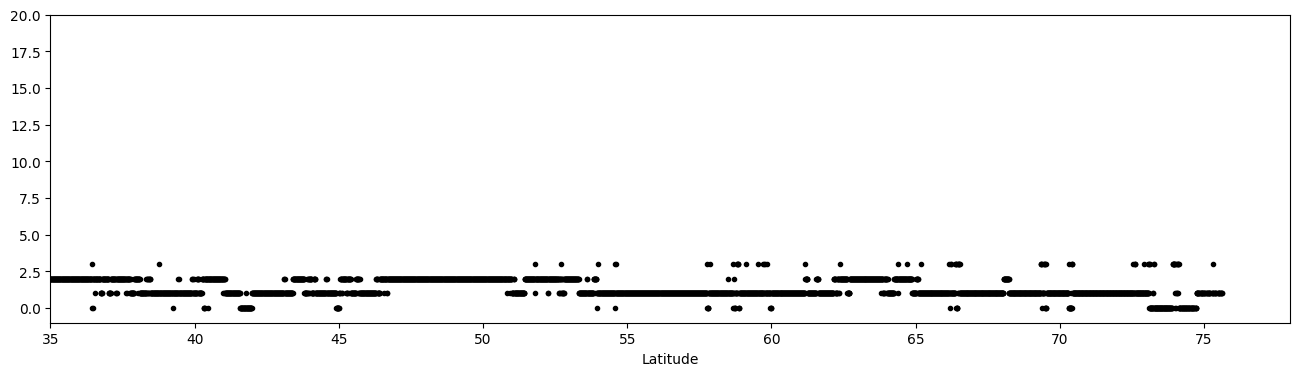

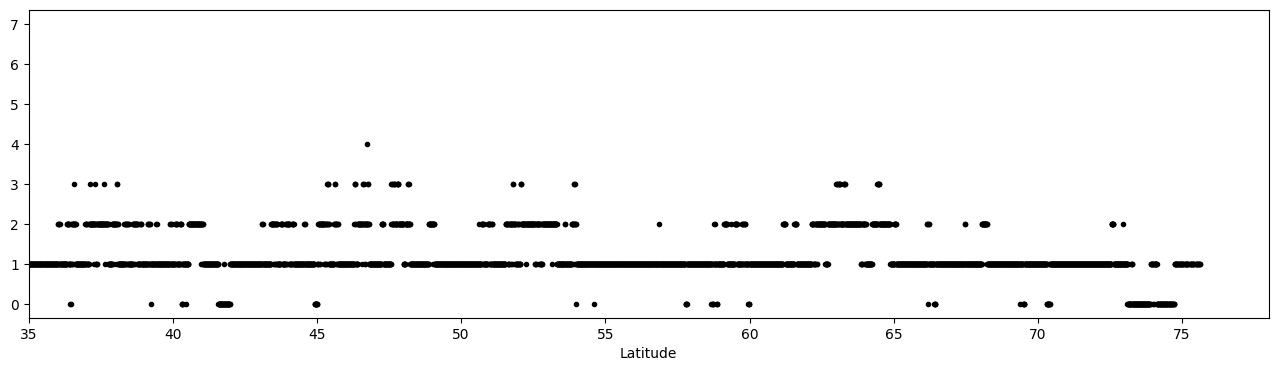

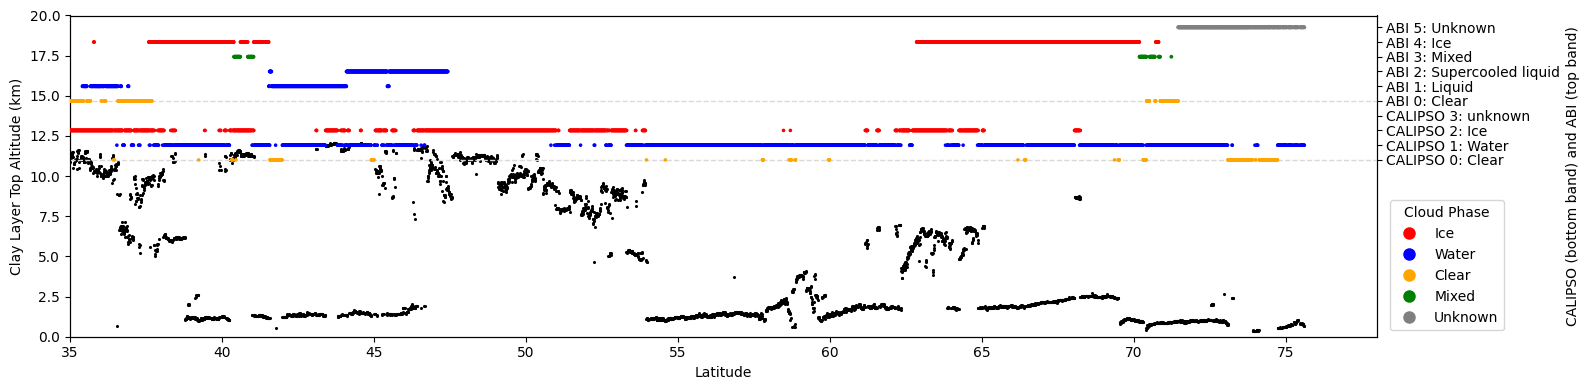

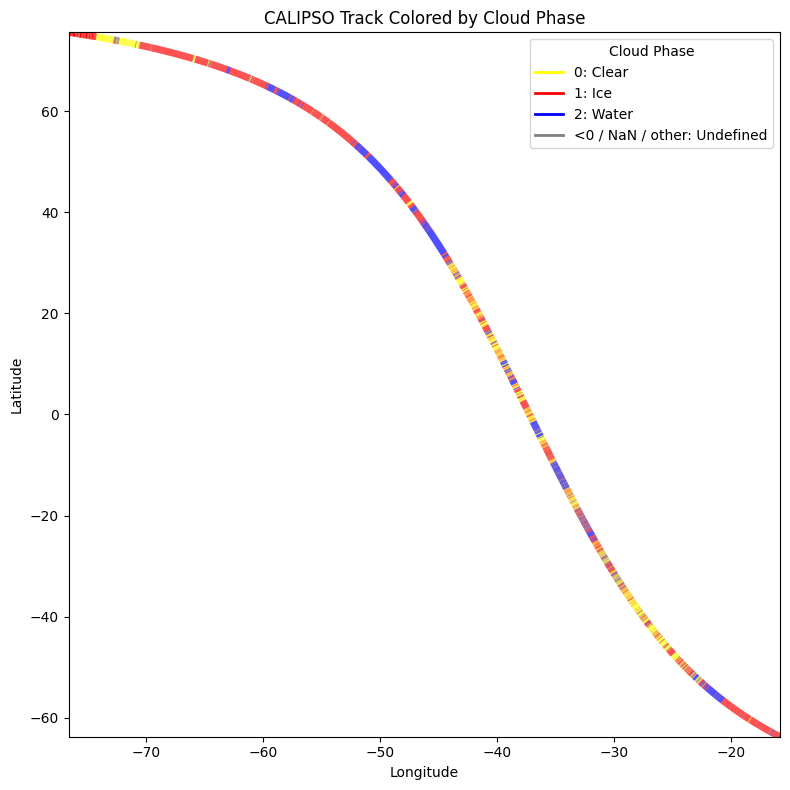

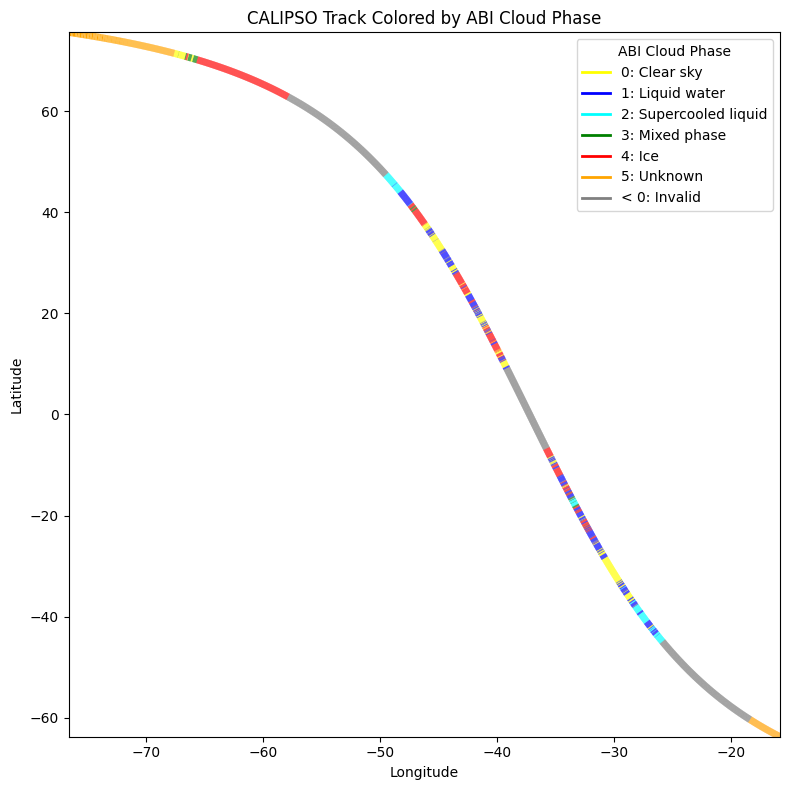

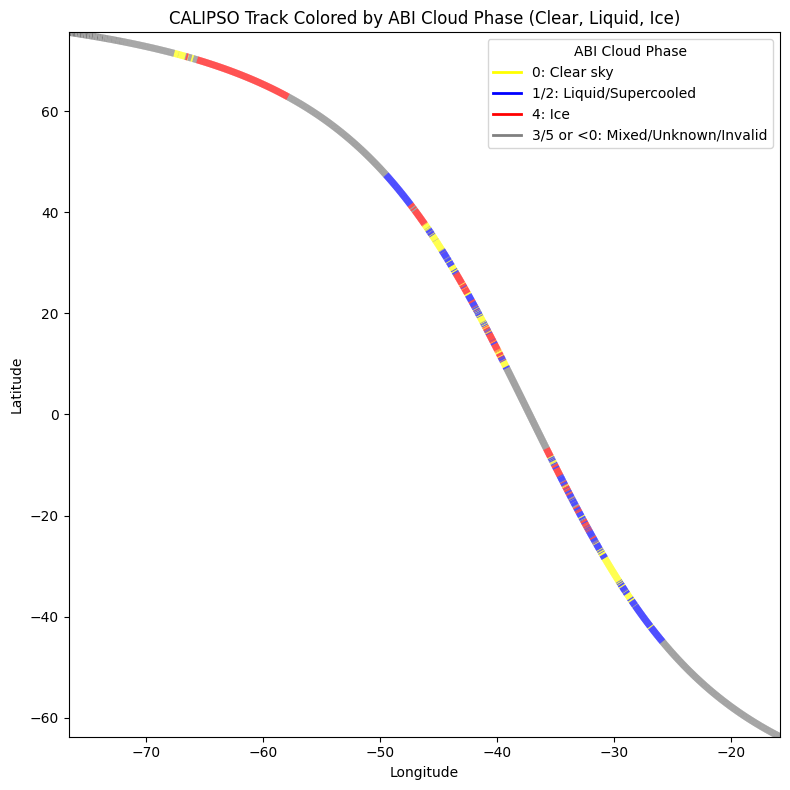

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


#df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T14-03-59ZD.h5')
df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape

#---- added by zhibo-------
new_ice_water_phase = np.full_like(ice_water_phase[:,0],-1)
new_ice_water_phase[np.logical_or(ice_water_phase[:,0]==1, ice_water_phase[:,0]==3)] = 2
new_ice_water_phase[ice_water_phase[:,0]==2] = 1
new_ice_water_phase[ice_water_phase[:,0]==65535] = 0
new_ice_water_phase[ice_water_phase[:,0]==0] = 3



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,new_ice_water_phase,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(new_ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(new_ice_water_phase) #.ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: WAT, 2: ICE, 3:UNK}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Water", 2: "CALIPSO 2: Ice",3: "CALIPSO 3: unknown"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2,3]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2,3]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = new_ice_water_phase #ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = new_ice_water_phase#ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)




=== CALIPSO feature_type ===
Total considered: 15,736 | Unique values: 2
value   2:     11,427  ( 72.62%)
value 65535:      4,309  ( 27.38%)

=== CALIPSO ice_water_phase ===
Total considered: 15,736 | Unique values: 4
value   0:      4,309  ( 27.38%)
value   1:      6,962  ( 44.24%)
value   2:      3,918  ( 24.90%)
value   3:        547  (  3.48%)

=== ABI Cloud Phase ===
Total considered: 15,736 | Unique values: 7
value -9999:      5,302  ( 33.69%)
value   0:      2,186  ( 13.89%)
value   1:      3,058  ( 19.43%)
value   2:      1,087  (  6.91%)
value   3:        192  (  1.22%)
value   4:      3,069  ( 19.50%)
value   5:        842  (  5.35%)


/tmp/ipython-input-2257964120.py:72: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T17-21-44ZD.h5')


(16765, 10) (16765, 1)
<class 'numpy.ndarray'>


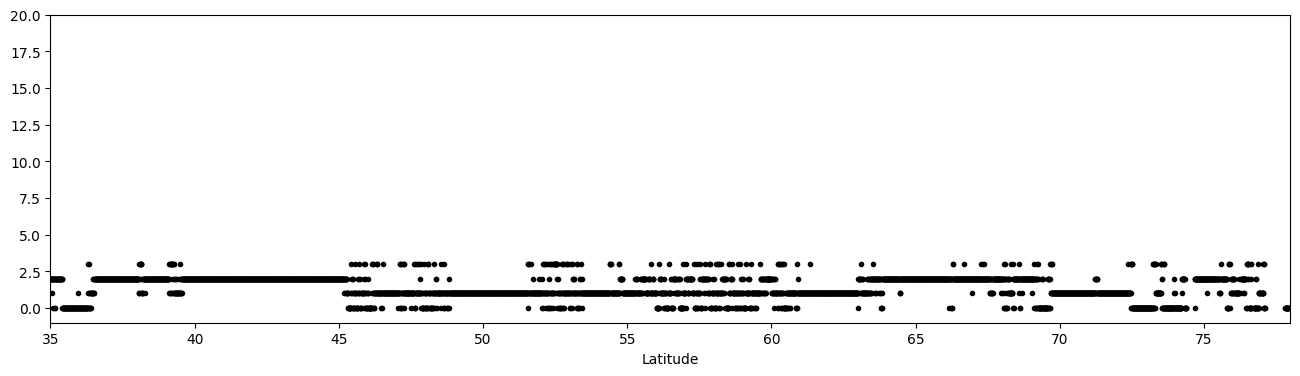

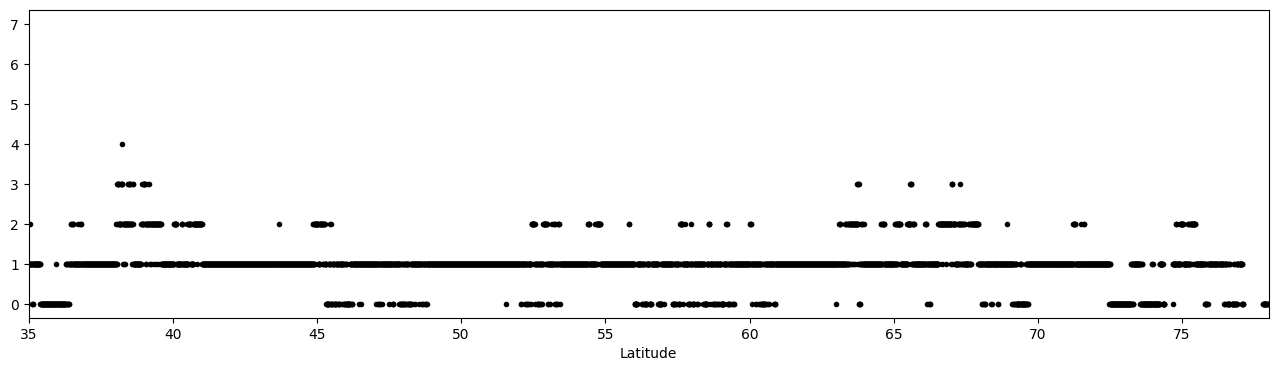

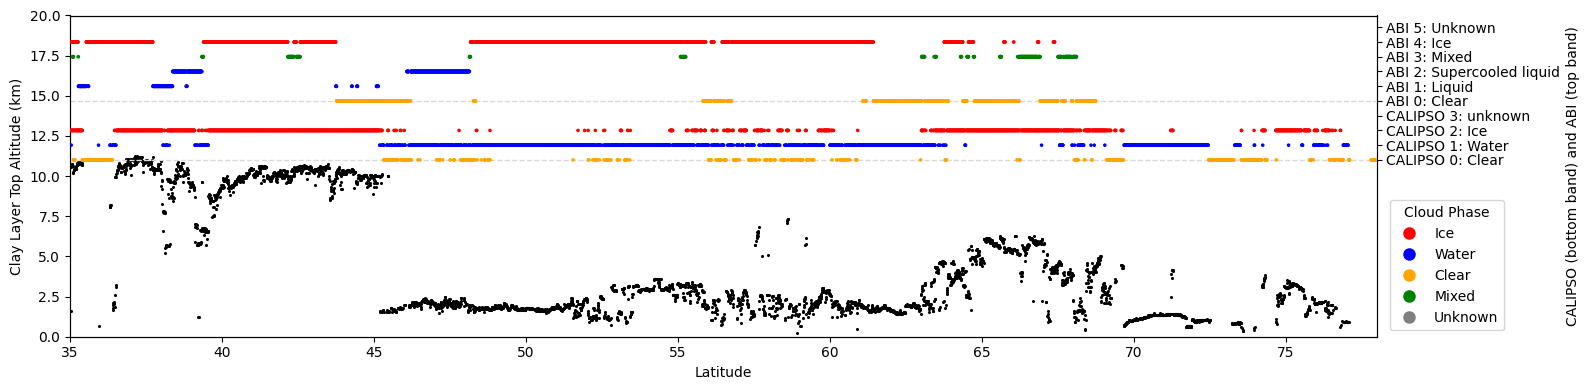

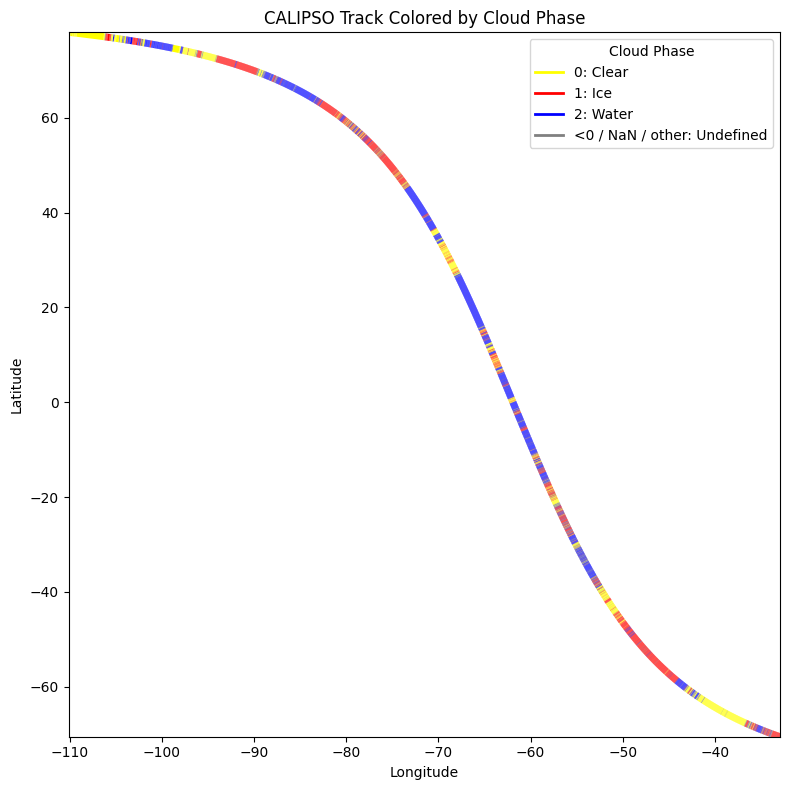

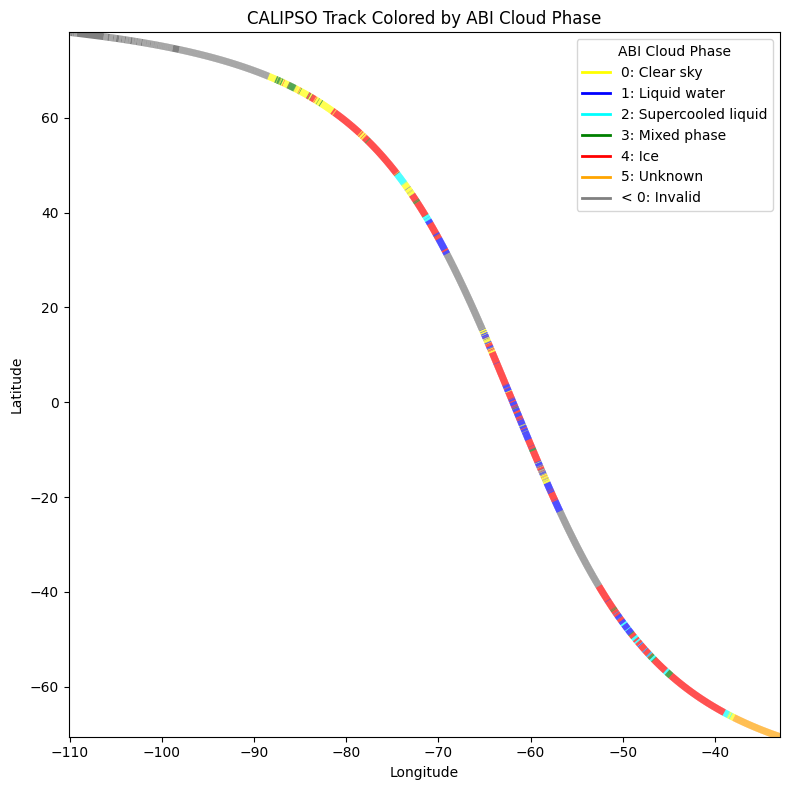

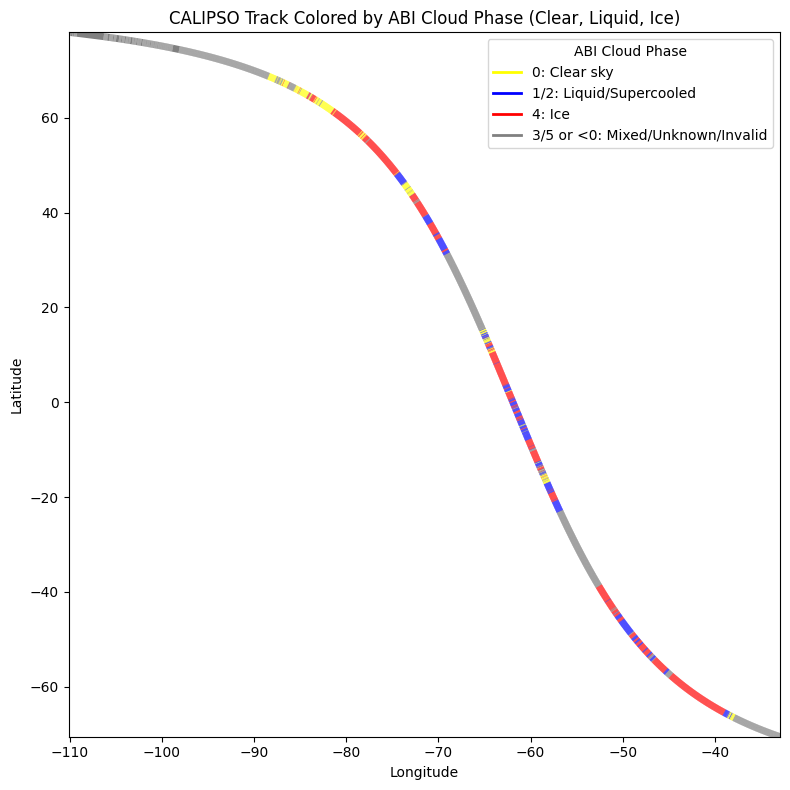

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


#df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T14-03-59ZD.h5')
df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T17-21-44ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape

#---- added by zhibo-------
new_ice_water_phase = np.full_like(ice_water_phase[:,0],-1)
new_ice_water_phase[np.logical_or(ice_water_phase[:,0]==1, ice_water_phase[:,0]==3)] = 2
new_ice_water_phase[ice_water_phase[:,0]==2] = 1
new_ice_water_phase[ice_water_phase[:,0]==65535] = 0
new_ice_water_phase[ice_water_phase[:,0]==0] = 3



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,new_ice_water_phase,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(new_ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(new_ice_water_phase) #.ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: WAT, 2: ICE, 3:UNK}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Water", 2: "CALIPSO 2: Ice",3: "CALIPSO 3: unknown"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2,3]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2,3]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = new_ice_water_phase #ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = new_ice_water_phase#ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)




=== CALIPSO feature_type ===
Total considered: 16,765 | Unique values: 2
value   2:     12,910  ( 77.01%)
value 65535:      3,855  ( 22.99%)

=== CALIPSO ice_water_phase ===
Total considered: 16,765 | Unique values: 4
value   0:      3,855  ( 22.99%)
value   1:      5,284  ( 31.52%)
value   2:      7,026  ( 41.91%)
value   3:        600  (  3.58%)

=== ABI Cloud Phase ===
Total considered: 16,765 | Unique values: 7
value -9999:      4,528  ( 27.01%)
value   0:      1,535  (  9.16%)
value   1:      2,507  ( 14.95%)
value   2:        663  (  3.95%)
value   3:        494  (  2.95%)
value   4:      6,549  ( 39.06%)
value   5:        489  (  2.92%)


/tmp/ipython-input-1260342936.py:72: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T19-00-39ZD.h5')


(16947, 10) (16947, 1)
<class 'numpy.ndarray'>


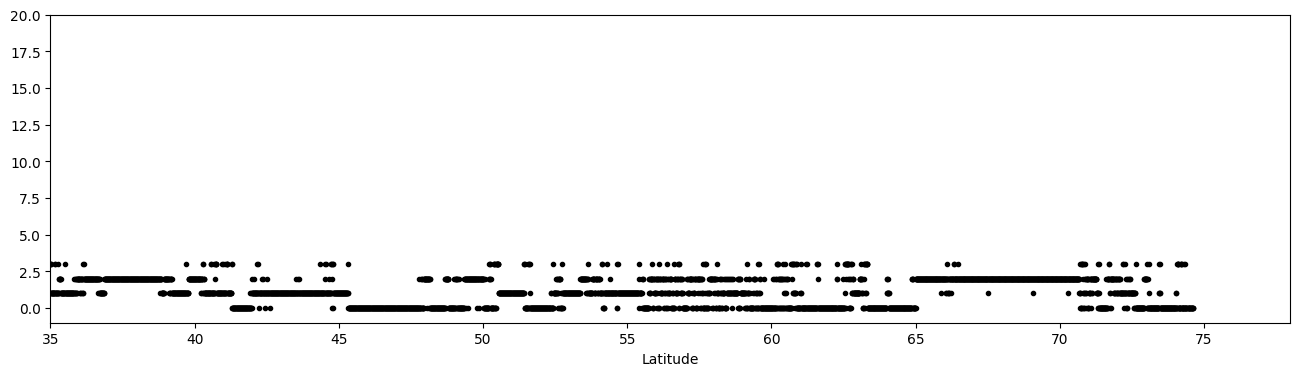

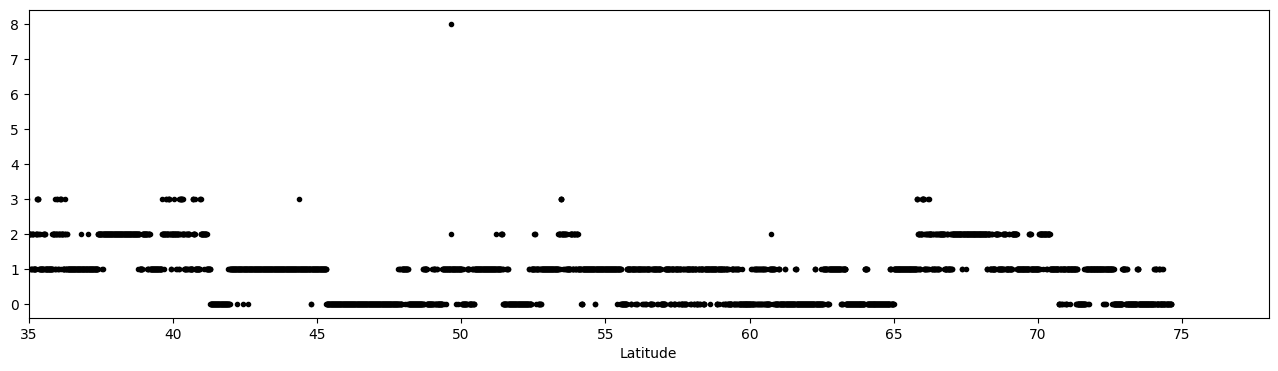

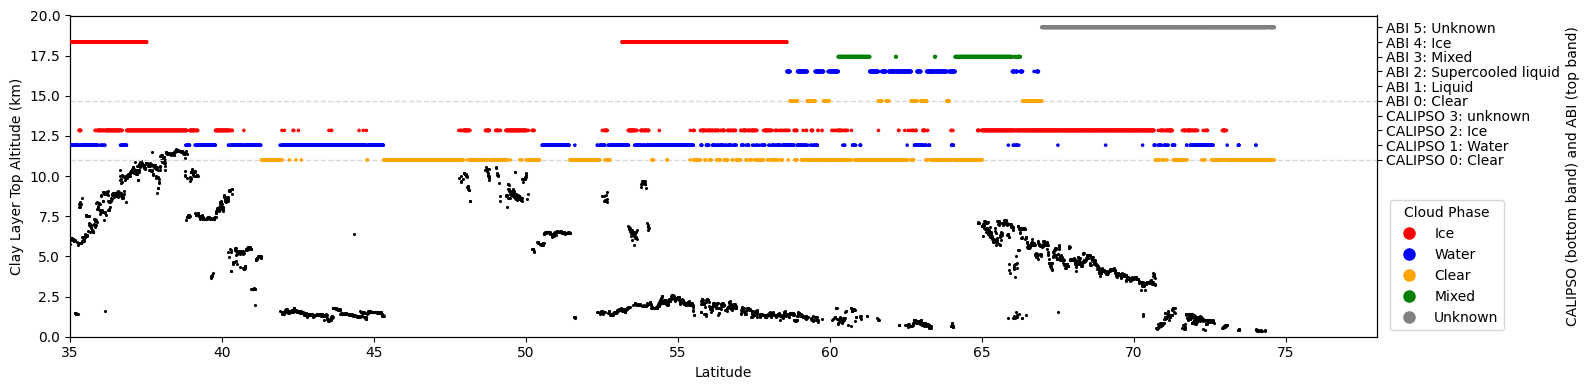

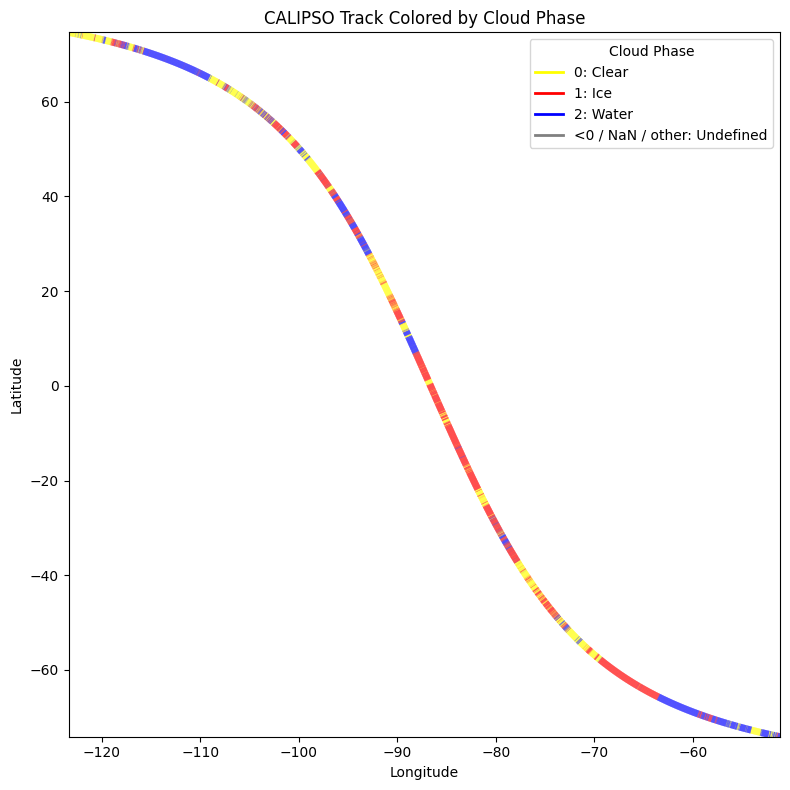

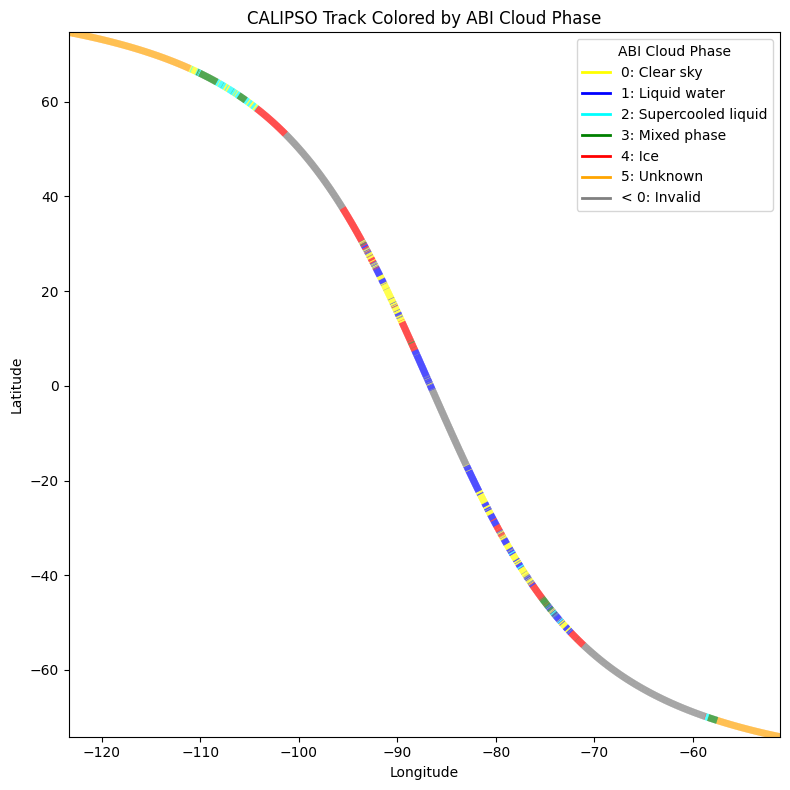

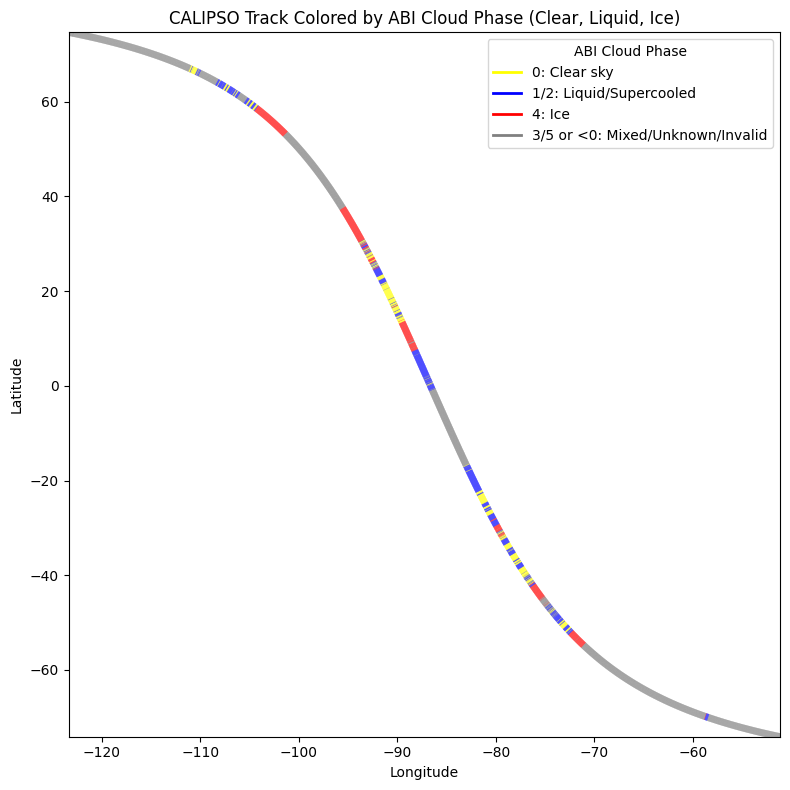

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


#df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T14-03-59ZD.h5')
df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T19-00-39ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape

#---- added by zhibo-------
new_ice_water_phase = np.full_like(ice_water_phase[:,0],-1)
new_ice_water_phase[np.logical_or(ice_water_phase[:,0]==1, ice_water_phase[:,0]==3)] = 2
new_ice_water_phase[ice_water_phase[:,0]==2] = 1
new_ice_water_phase[ice_water_phase[:,0]==65535] = 0
new_ice_water_phase[ice_water_phase[:,0]==0] = 3



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,new_ice_water_phase,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(new_ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(new_ice_water_phase) #.ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: WAT, 2: ICE, 3:UNK}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Water", 2: "CALIPSO 2: Ice",3: "CALIPSO 3: unknown"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2,3]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2,3]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = new_ice_water_phase #ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = new_ice_water_phase#ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)




=== CALIPSO feature_type ===
Total considered: 16,947 | Unique values: 2
value   2:     11,901  ( 70.22%)
value 65535:      5,046  ( 29.78%)

=== CALIPSO ice_water_phase ===
Total considered: 16,947 | Unique values: 4
value   0:      5,046  ( 29.78%)
value   1:      7,850  ( 46.32%)
value   2:      3,766  ( 22.22%)
value   3:        285  (  1.68%)

=== ABI Cloud Phase ===
Total considered: 16,947 | Unique values: 7
value -9999:      5,303  ( 31.29%)
value   0:      2,694  ( 15.90%)
value   1:      3,250  ( 19.18%)
value   2:        529  (  3.12%)
value   3:        725  (  4.28%)
value   4:      3,071  ( 18.12%)
value   5:      1,375  (  8.11%)


# Old wrong Calipso Labels

/tmp/ipython-input-3604816785.py:71: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5')


(15736, 10) (15736, 1)
<class 'numpy.ndarray'>


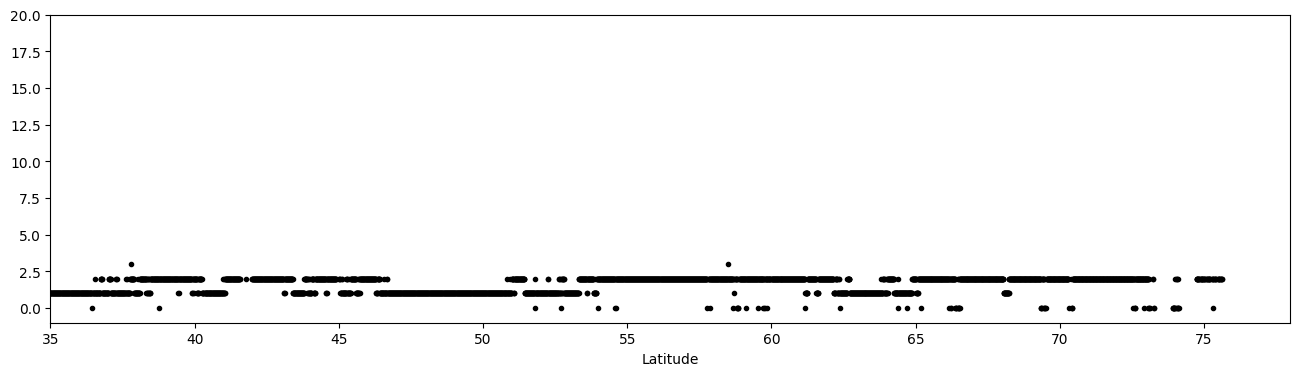

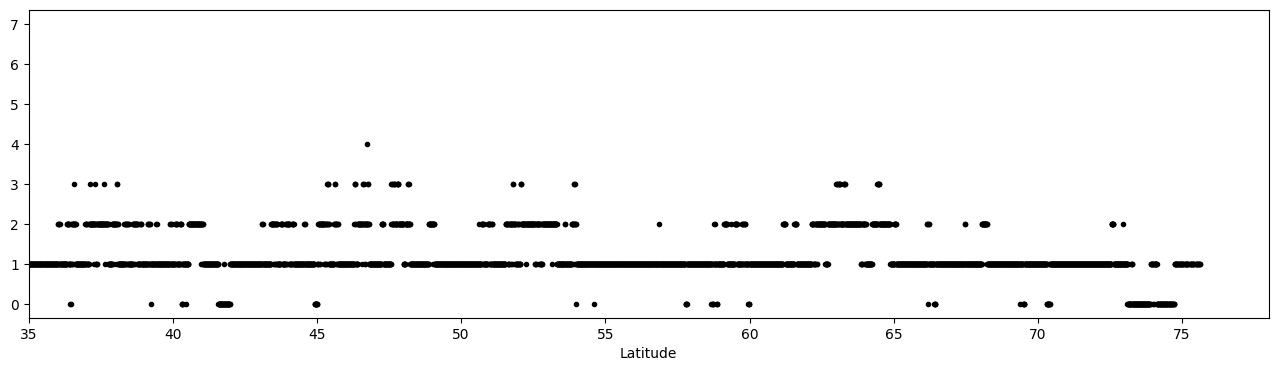

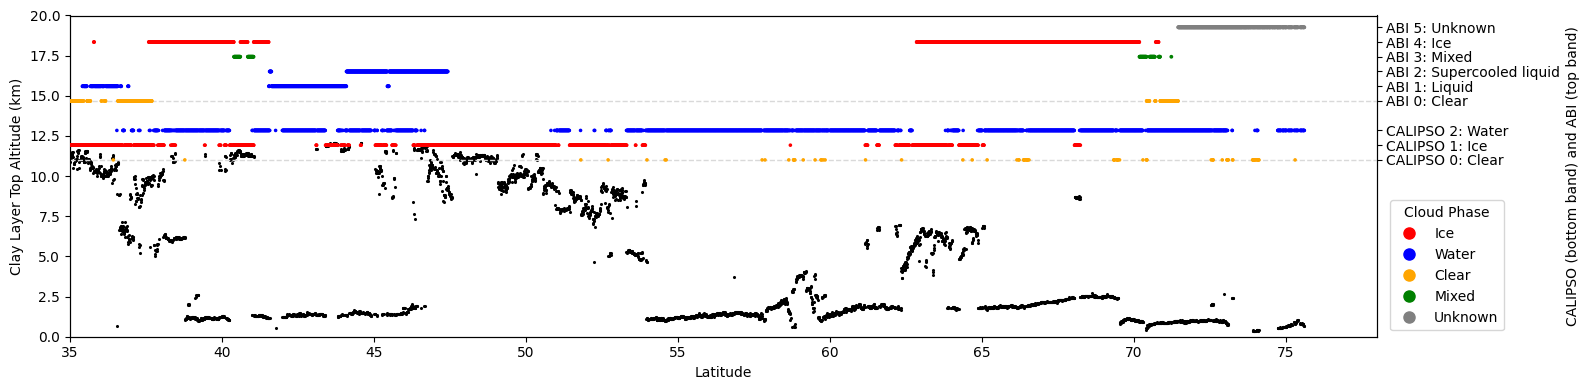

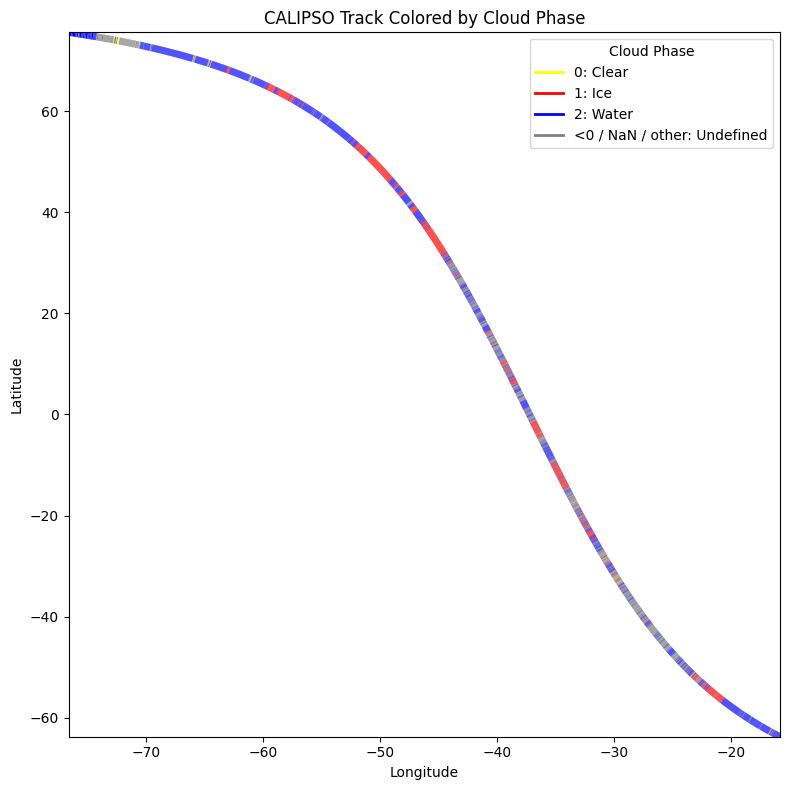

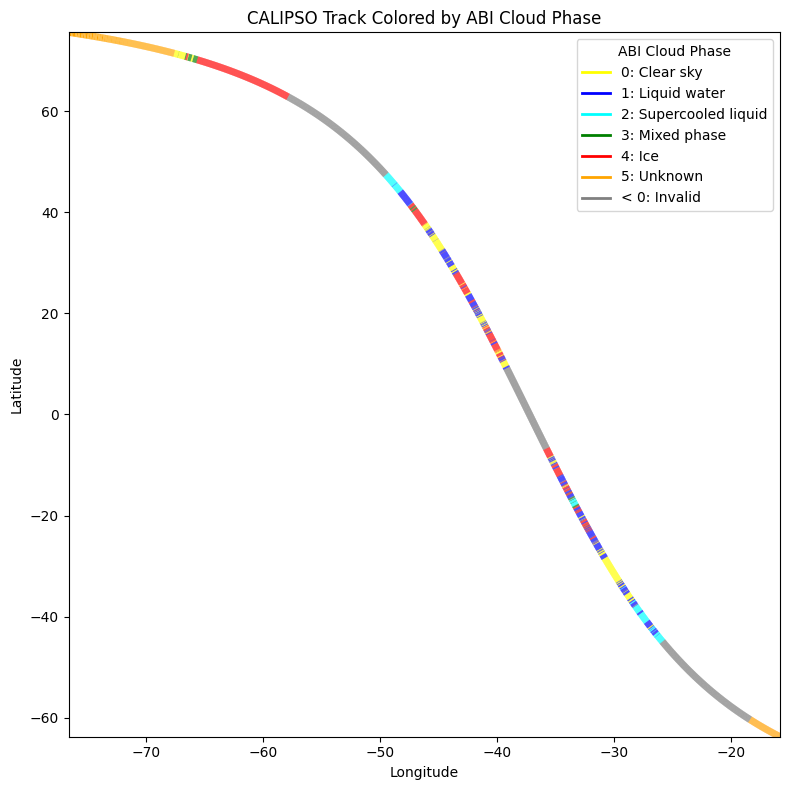

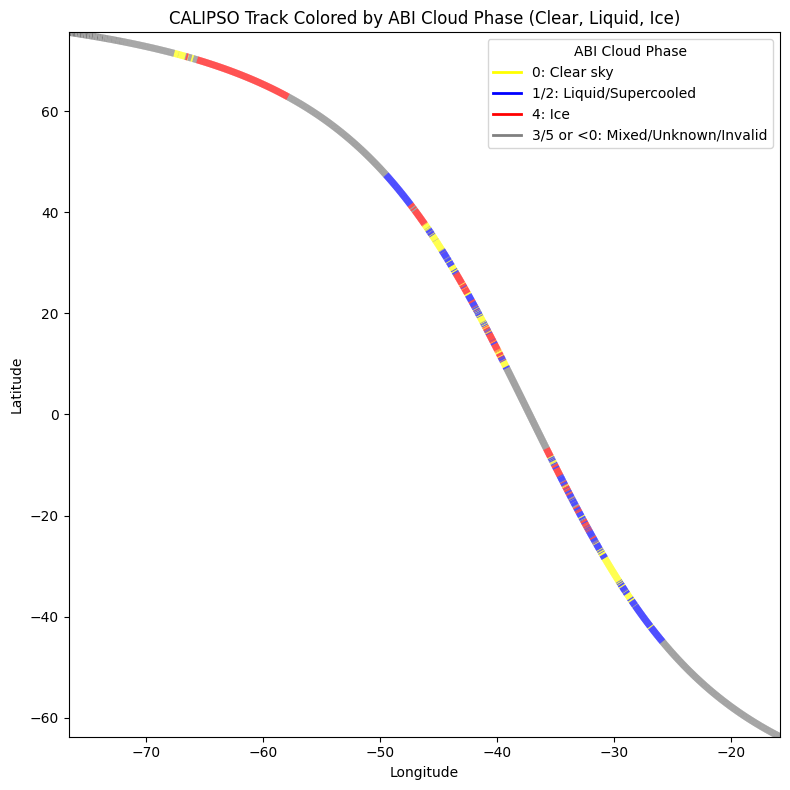

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T15-42-49ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,ice_water_phase[:,0],
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(ice_water_phase[:, 0]).ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: ICE, 2: WAT}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Ice", 2: "CALIPSO 2: Water"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)

#



=== CALIPSO feature_type ===
Total considered: 15,736 | Unique values: 2
value   2:     11,427  ( 72.62%)
value 65535:      4,309  ( 27.38%)

=== CALIPSO ice_water_phase ===
Total considered: 15,736 | Unique values: 5
value   0:        547  (  3.48%)
value   1:      3,897  ( 24.76%)
value   2:      6,962  ( 44.24%)
value   3:         21  (  0.13%)
value 65535:      4,309  ( 27.38%)

=== ABI Cloud Phase ===
Total considered: 15,736 | Unique values: 7
value -9999:      5,302  ( 33.69%)
value   0:      2,186  ( 13.89%)
value   1:      3,058  ( 19.43%)
value   2:      1,087  (  6.91%)
value   3:        192  (  1.22%)
value   4:      3,069  ( 19.50%)
value   5:        842  (  5.35%)


/tmp/ipython-input-1955991713.py:71: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T17-21-44ZD.h5')


(16765, 10) (16765, 1)
<class 'numpy.ndarray'>


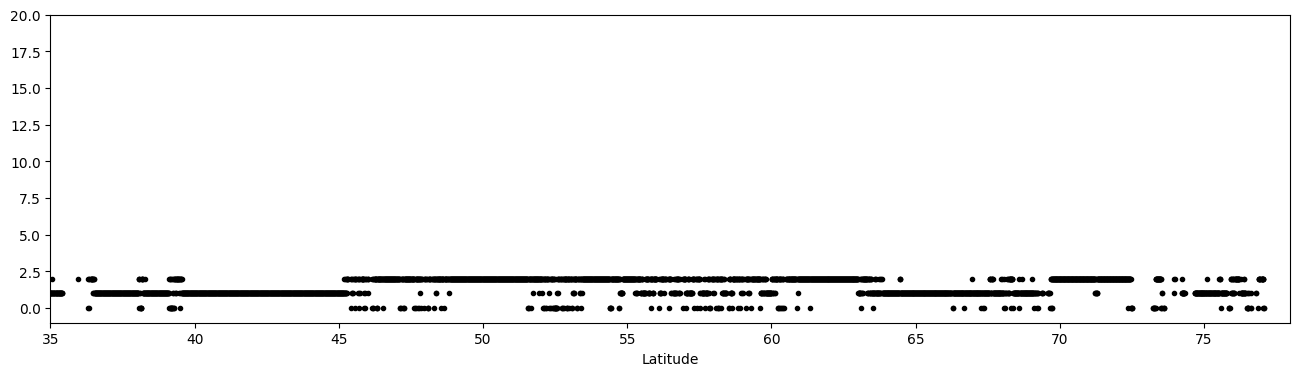

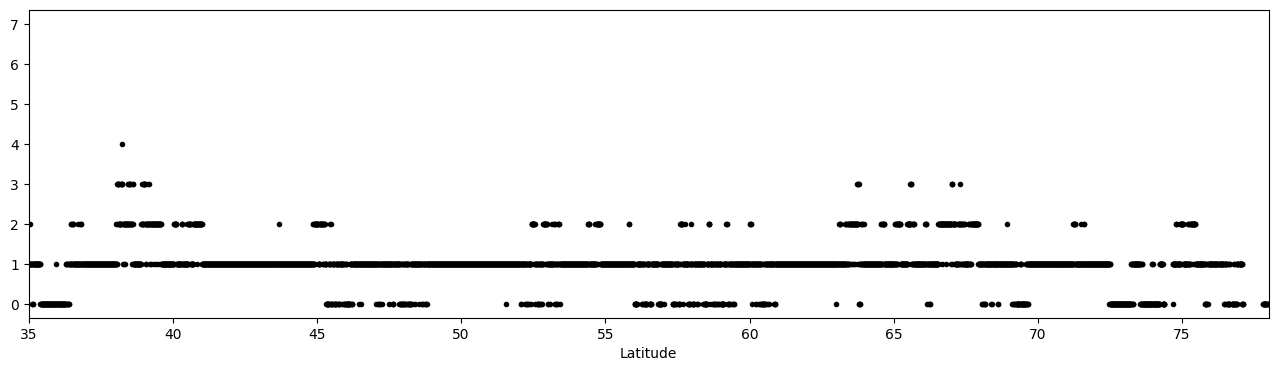

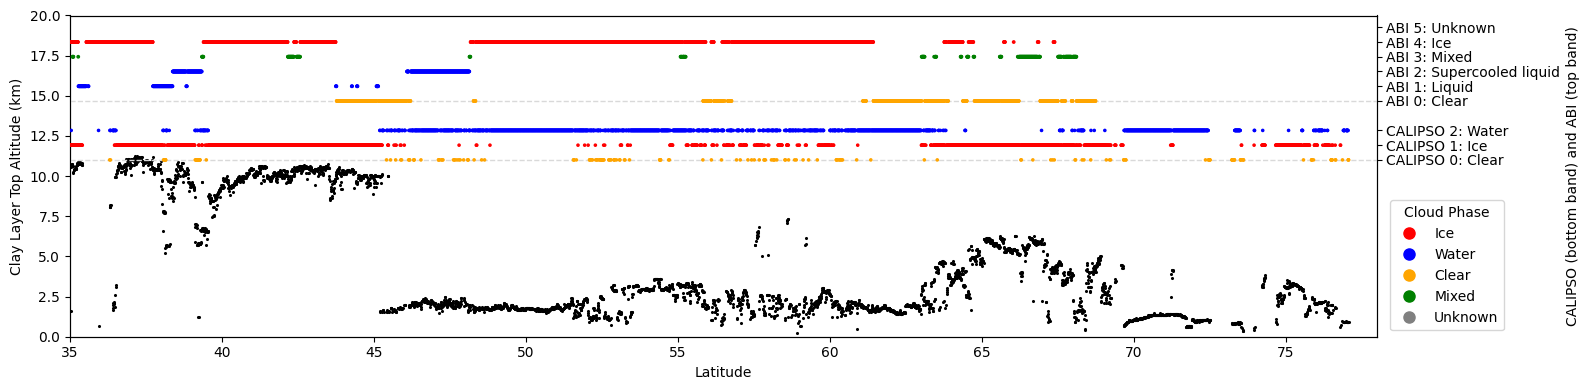

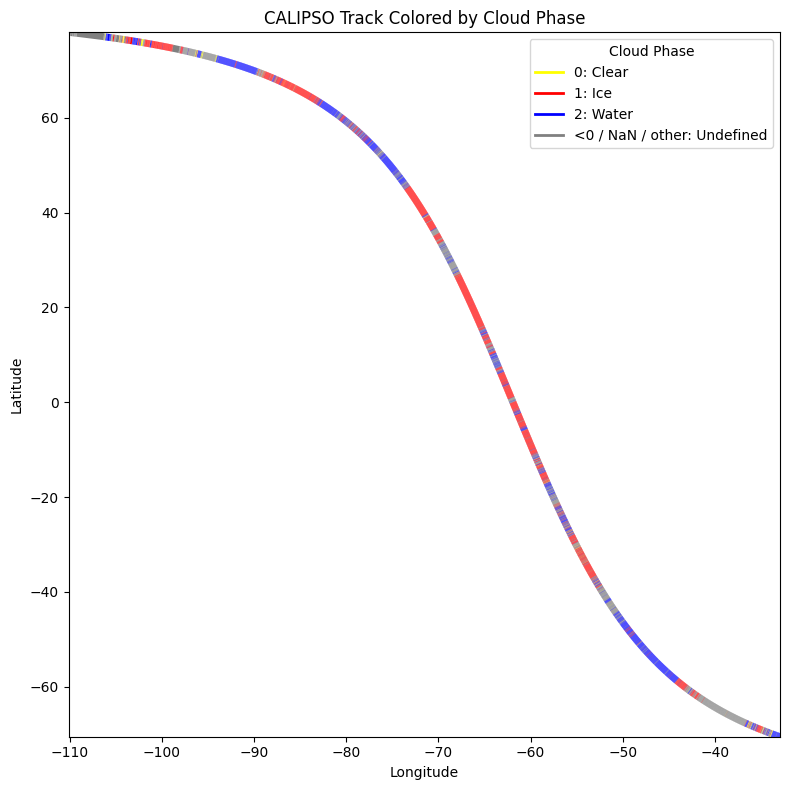

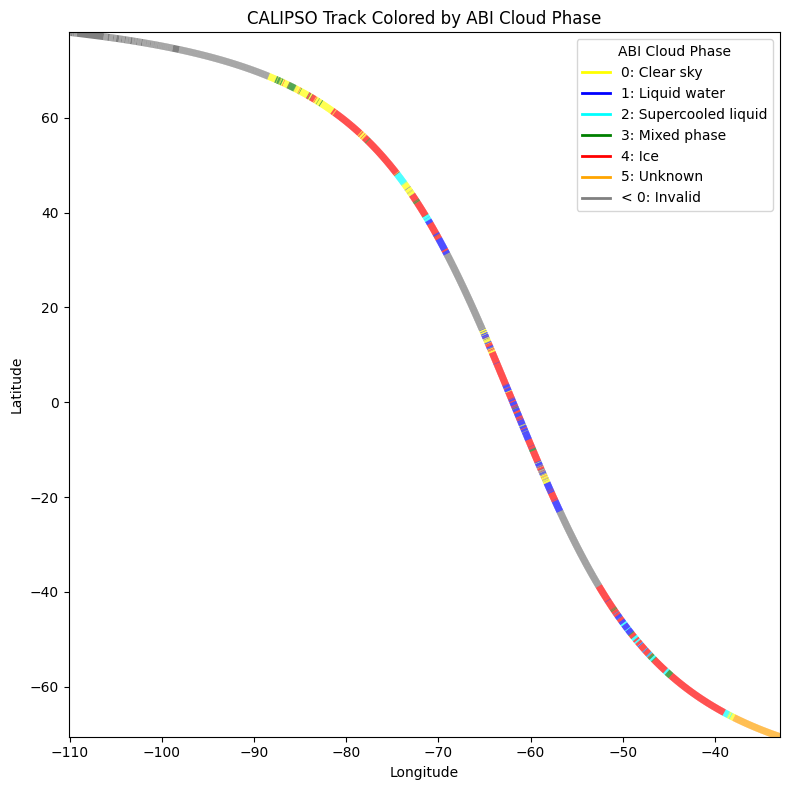

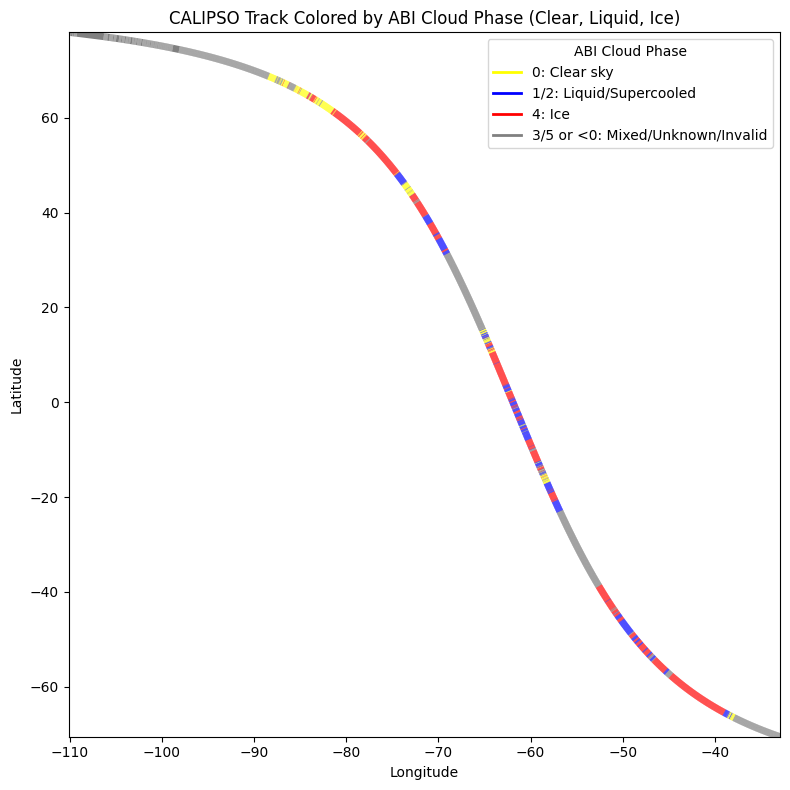

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T17-21-44ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,ice_water_phase[:,0],
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(ice_water_phase[:, 0]).ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: ICE, 2: WAT}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Ice", 2: "CALIPSO 2: Water"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)

#



=== CALIPSO feature_type ===
Total considered: 16,765 | Unique values: 2
value   2:     12,910  ( 77.01%)
value 65535:      3,855  ( 22.99%)

=== CALIPSO ice_water_phase ===
Total considered: 16,765 | Unique values: 5
value   0:        600  (  3.58%)
value   1:      6,991  ( 41.70%)
value   2:      5,284  ( 31.52%)
value   3:         35  (  0.21%)
value 65535:      3,855  ( 22.99%)

=== ABI Cloud Phase ===
Total considered: 16,765 | Unique values: 7
value -9999:      4,528  ( 27.01%)
value   0:      1,535  (  9.16%)
value   1:      2,507  ( 14.95%)
value   2:        663  (  3.95%)
value   3:        494  (  2.95%)
value   4:      6,549  ( 39.06%)
value   5:        489  (  2.92%)


/tmp/ipython-input-4105202482.py:71: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T19-00-39ZD.h5')


(16947, 10) (16947, 1)
<class 'numpy.ndarray'>


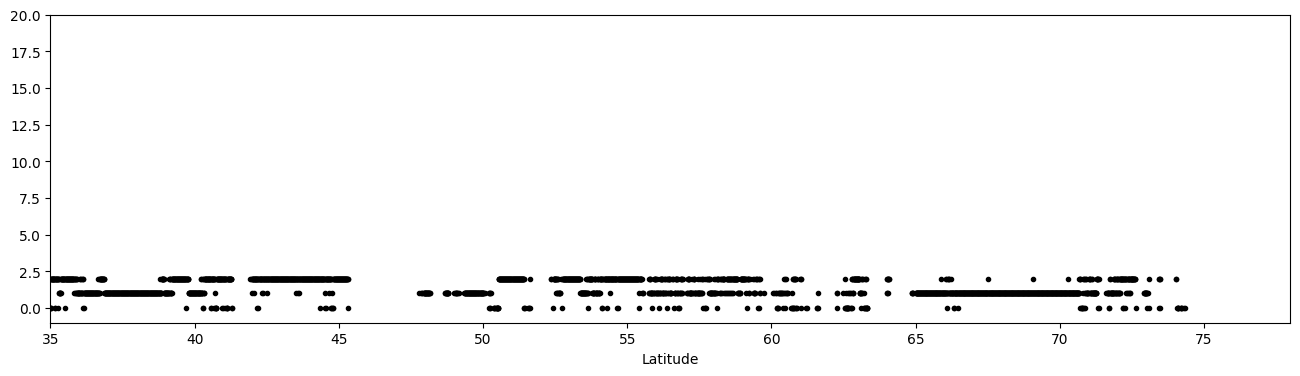

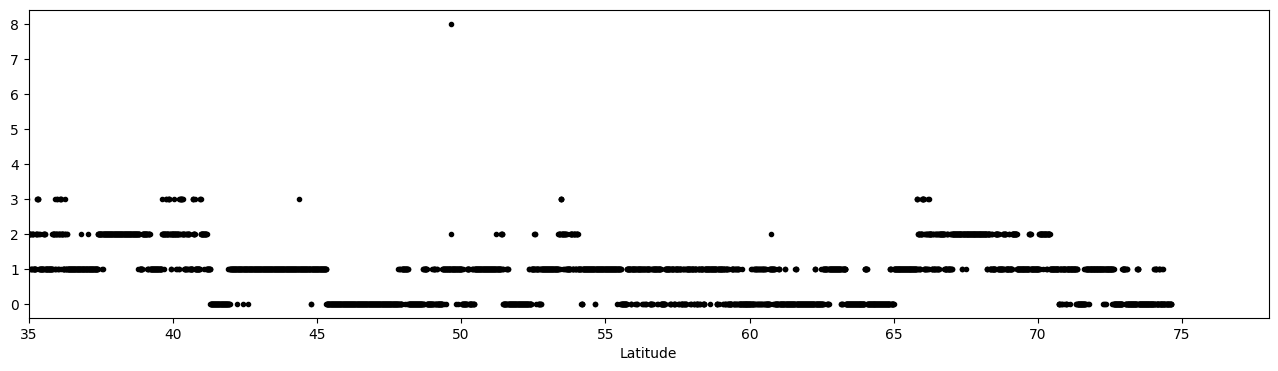

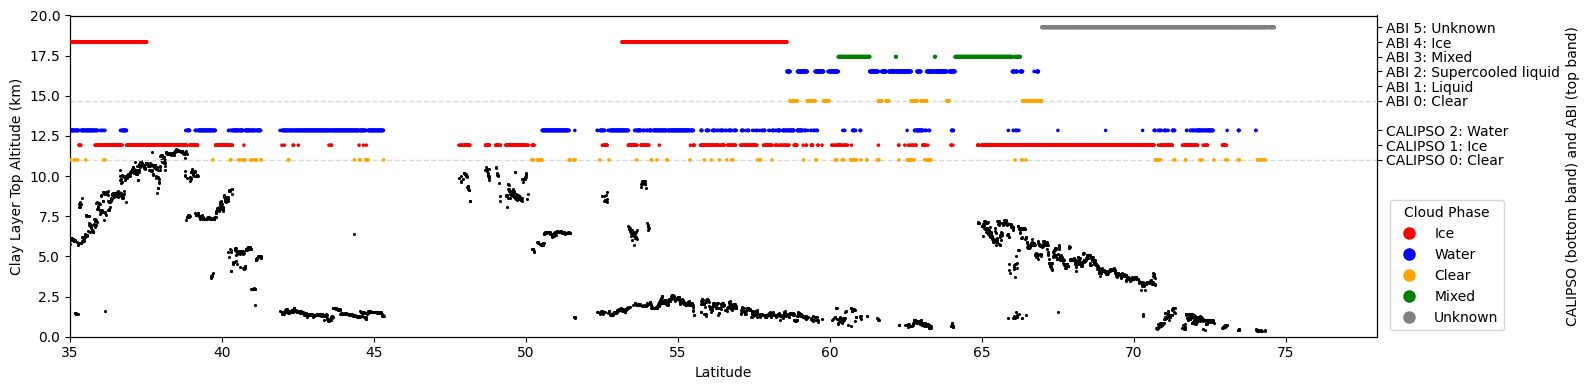

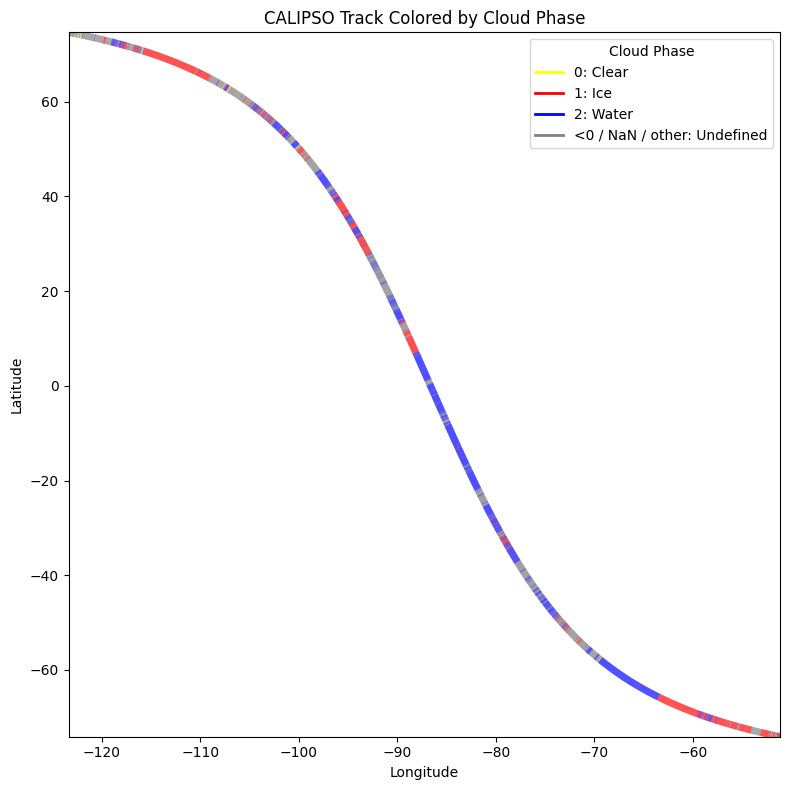

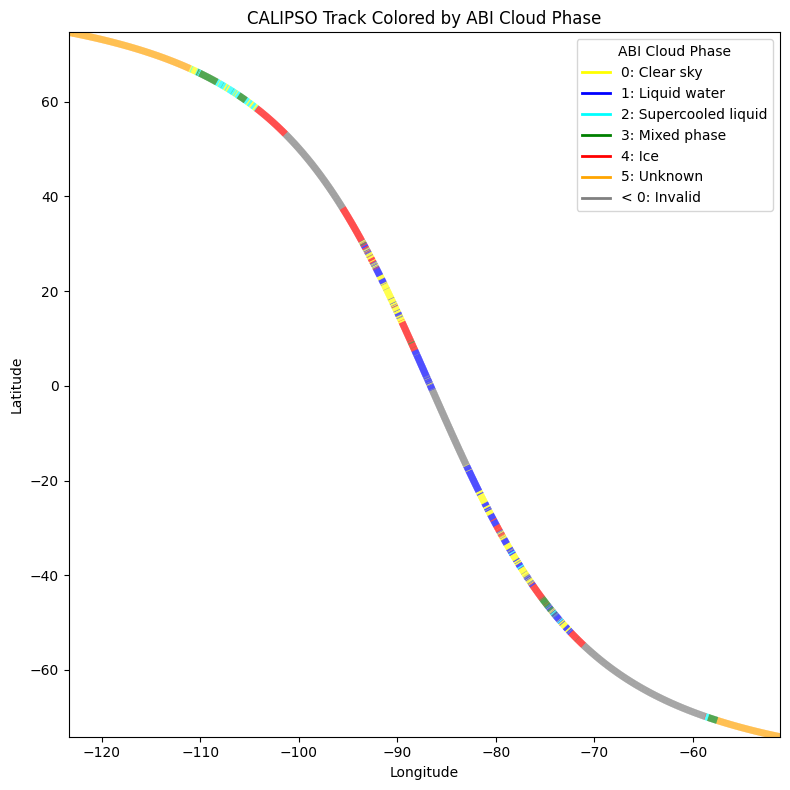

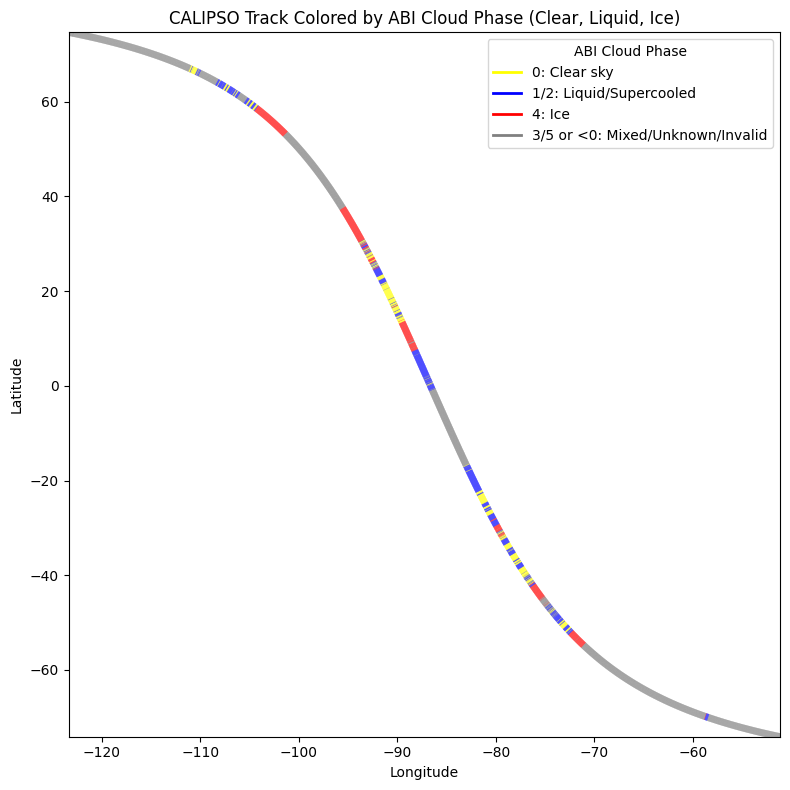

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


def Extract_Feature_Info(vfm_array,nlay):
    npro = nlay.size
    print(vfm_array.shape,nlay.shape)
    print(type(vfm_array))
    feature_type    = np.full_like(vfm_array,-1)
    feature_type_qa = np.full_like(vfm_array,-1)
    ice_water_phase = np.full_like(vfm_array,-1)
    ice_water_phase_qa = np.full_like(vfm_array,-1)
    feature_subtype = np.full_like(vfm_array,-1)
    cloud_aerosol_psc_type_qa = np.full_like(vfm_array,-1)
    horizontal_averaging = np.full_like(vfm_array,-1)
    for i in range(npro):
        # print('profile ',i,'number of layers detected',nlay[i,0])
        for l in range(nlay[i,0]):
            #print('number of layers',nlay[i][0])
            (
                feature_type_val,
                feature_type_qa_val,
                ice_water_phase_val,
                ice_water_phase_qa_val,
                feature_subtype_val,
                cloud_aerosol_psc_type_qa_val,
                horizontal_averaging_val,
            ) = vfm_feature_flags(vfm_array[i, l])

            feature_type[i, l] = feature_type_val
            feature_type_qa[i, l] = feature_type_qa_val
            ice_water_phase[i, l] = ice_water_phase_val
            ice_water_phase_qa[i, l] = ice_water_phase_qa_val
            feature_subtype[i, l] = feature_subtype_val
            cloud_aerosol_psc_type_qa[i, l] = cloud_aerosol_psc_type_qa_val
            horizontal_averaging[i, l] = horizontal_averaging_val


    return feature_type, feature_type_qa,ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa, horizontal_averaging

def vfm_feature_flags(val,verbose=False):

#  this routine demonstrates how to read and extract values from a feature
#  classification flag 16-bit integer value in CALIPSO Level 2 Vertical
#  Feature Mask files
#
#  INPUT:
#  val - the feature classification flag value to be decoded
#
#  OUTPUT:
#  all information is printed into the IDL log window

    val_bit = np.binary_repr(val)
    # print('val_bit',val_bit)
    feature_type              = int(val_bit[-3:],2)
    # print(val_bit[-3:],2)
    feature_type_qa           = int(val_bit[-5:-3],2)
    ice_water_phase           = int(val_bit[-7:-5],2)
    ice_water_phase_qa        = int(val_bit[-9:-7],2)
    feature_subtype           = int(val_bit[-12:-9],2)
    cloud_aerosol_psc_type_qa = int(val_bit[-13],2)
    horizontal_averaging      = int(val_bit[-16:-13],2)
    return feature_type, feature_type_qa,\
    ice_water_phase, ice_water_phase_qa,\
    feature_subtype, cloud_aerosol_psc_type_qa,\
    horizontal_averaging


df = xr.open_dataset('/content/drive/MyDrive/NasaAccessCode/ABI_Data/allData/domainAdaptive/Testing_trainData/train/ABI_G16_Data_CAL_2017-11-07T19-00-39ZD.h5')

feature_type,feature_type_qa,\
ice_water_phase,ice_water_phase_qa,\
feature_subtype,cloud_aerosol_psc_type_qa,hv = Extract_Feature_Info(df.CALIOP_Clay_Feature_Classification_Flags_1km.values,\
                                                                 df.CALIOP_N_Clay_1km.values)
# see this
feature_type.shape



fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,ice_water_phase[:,0],
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])
ax.set_ylim([-1,20])



np.unique(ice_water_phase)

fig,ax=plt.subplots(figsize=(16,4))
ax.scatter(df.CALIPSO_Lat,df.CALIOP_N_Clay_1km,
           marker='.',c='k')
ax.set_xlabel('Latitude')
ax.set_xlim([35,78])


# ===== Altitude on left; CALIPSO & ABI phases stacked ABOVE; single combined legend =====
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16, 4))
fig.subplots_adjust(right=0.82)  # leave room for one legend on the right

# Left axis — altitude (km)
lat = np.asarray(df['CALIPSO_Lat']).ravel()
alt = np.asarray(df['CALIOP_Clay_Layer_Top_Altitude_1km'][:, 0]).ravel()
ax.scatter(lat, alt, marker='.', c='k', s=6, zorder=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Clay Layer Top Altitude (km)')
ax.set_xlim(35, 78)
ax.set_ylim(0, 20)

# Right axis — stacked phase bands
axr = ax.twinx()

# Data
cal_phase = np.asarray(ice_water_phase[:, 0]).ravel()
abi_all   = np.asarray(df['ABI_Cloud_Phase']).ravel()
N = min(lat.size, cal_phase.size, abi_all.size)
latN, calN, abiN = lat[:N], cal_phase[:N], abi_all[:N]

# Band baselines (no overlap with altitude)
CAL_BASE = 12.0   # CALIPSO band y = 12 + phase(0..2)
ABI_BASE = 16.0   # ABI band     y = 16 + phase(0..5)

# ---- Colors (shared legend semantics) ----
CLR  = 'orange'  # Clear
WAT  = 'blue'    # Water (incl. ABI 1 & 2)
MIX  = 'green'   # Mixed
ICE  = 'red'     # Ice
UNK  = 'gray'    # Unknown

CAL_COLORS = {0: CLR, 1: ICE, 2: WAT}                         # CALIPSO 0/1/2
ABI_COLORS = {0: CLR, 1: WAT, 2: WAT, 3: MIX, 4: ICE, 5: UNK} # ABI 0..5

def map_colors(values, cmap, default='gray'):
    v = np.asarray(values).astype(int)
    out = np.full(v.shape, default, dtype=object)
    for k, c in cmap.items():
        out[v == k] = c
    return out

# ---- CALIPSO scatter (0/1/2 only) ----
cal_mask = np.isfinite(calN) & np.isin(calN, [0, 1, 2])
cal_y    = CAL_BASE + calN[cal_mask]
cal_cols = map_colors(calN[cal_mask], CAL_COLORS)
axr.scatter(latN[cal_mask], cal_y, marker='.', c=cal_cols, s=10, zorder=3)

# ---- ABI scatter (0..5) ----
abi_mask = np.isfinite(abiN) & (abiN >= 0)
abi_y    = ABI_BASE + abiN[abi_mask]
abi_cols = map_colors(abiN[abi_mask], ABI_COLORS)
axr.scatter(latN[abi_mask], abi_y, marker='.', c=abi_cols, s=12, zorder=4)

# Band separators
axr.axhline(CAL_BASE, color='0.85', lw=1, ls='--', zorder=1)
axr.axhline(ABI_BASE, color='0.85', lw=1, ls='--', zorder=1)

# Right-axis ticks & labels
calipso_labels = {0: "CALIPSO 0: Clear", 1: "CALIPSO 1: Ice", 2: "CALIPSO 2: Water"}
abi_labels     = {0: "ABI 0: Clear", 1: "ABI 1: Liquid", 2: "ABI 2: Supercooled liquid",
                  3: "ABI 3: Mixed", 4: "ABI 4: Ice", 5: "ABI 5: Unknown"}
cal_ticks = [CAL_BASE + k for k in [0,1,2]]
abi_ticks = [ABI_BASE + k for k in [0,1,2,3,4,5]]
axr.set_yticks(cal_ticks + abi_ticks)
axr.set_yticklabels([calipso_labels[k] for k in [0,1,2]] +
                    [abi_labels[k]     for k in [0,1,2,3,4,5]])
axr.set_ylabel('CALIPSO (bottom band) and ABI (top band)')
axr.set_ylim(0, ABI_BASE + 5 + 0.8)

# ---- Single combined legend (describes colors for BOTH datasets) ----
handles = [
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=ICE, markeredgecolor=ICE, label='Ice'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=WAT, markeredgecolor=WAT, label='Water'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=CLR, markeredgecolor=CLR, label='Clear'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=MIX, markeredgecolor=MIX, label='Mixed'),
    Line2D([0],[0], marker='o', markersize=8, linestyle='None',
           markerfacecolor=UNK, markeredgecolor=UNK, label='Unknown'),
]
axr.legend(handles=handles, title='Cloud Phase',
           loc='lower left', bbox_to_anchor=(1.01, 0.02), borderaxespad=0., frameon=True)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# 1) Extract 1-D arrays of lon, lat, and phase
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

#  change thie to the top most layer
phases = ice_water_phase[:,0]



# 2) Map each phase to a color
# 2) Map each phase to a color
ph = np.asarray(phases, dtype=float)          # allow NaNs
colors = np.full(ph.shape, 'gray', dtype=object)   # default = undefined/invalid

colors[ph == 0] = 'yellow'    # Clear
colors[ph == 1] = 'red'       # Ice
colors[ph == 2] = 'blue'      # Water
# Note: values < 0, NaN, or not in {0,1,2} remain gray

# 3) Build line segments between successive points
points = np.column_stack((x, y))  # shape (N, 2)
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 4) Create a LineCollection: one color per segment
lc = LineCollection(segments,
                    colors=colors[:-1],   # length N-1 to match segments
                    linewidths=5)

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by Cloud Phase')

# 6) Legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear'),
    Line2D([0], [0], color='red',    linewidth=2, label='1: Ice'),
    Line2D([0], [0], color='blue',   linewidth=2, label='2: Water'),
    Line2D([0], [0], color='gray',   linewidth=2, label='<0 / NaN / other: Undefined')
]
ax.legend(handles=legend_elements, title='Cloud Phase', loc='best')

plt.tight_layout()
plt.show()



df['CALIOP_N_Clay_1km'].shape





# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()    # shape (N,)
y = df['CALIPSO_Lat'].to_numpy().ravel()    # shape (N,)

# 2) Extract your ABI phase array
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()  # shape (N,)

# 3) Define a color map for valid phases, and gray for negatives
phase_colors = {
    0: 'yellow',#clear
    1: 'blue',#Liquid
    2: 'cyan',#supercooled liquid
    3: 'green', # Mixed
    4: 'red', # Ice
    5: 'orange'#
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Build line segments between successive points
points   = np.column_stack((x, y))                   # (N, 2)
segments = [[points[i], points[i+1]]
            for i in range(len(points)-1)]           # (N-1) of (2,2)

# 5) Create and add a LineCollection (no legend)
lc = LineCollection(segments,
                    colors=colors[:-1],  # one color per segment
                    linewidths=5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)

# 6) Frame the plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase')
# Add legend with detailed ABI labels
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1: Liquid water'),
    Line2D([0], [0], color='cyan', linewidth=2, label='2: Supercooled liquid'),
    Line2D([0], [0], color='green', linewidth=2, label='3: Mixed phase'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='orange', linewidth=2, label='5: Unknown'),
    Line2D([0], [0], color='gray', linewidth=2, label='< 0: Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')


plt.tight_layout()
plt.show()


# 1) Extract 1-D lon/lat arrays
x = df['CALIPSO_Lon'].to_numpy().ravel()
y = df['CALIPSO_Lat'].to_numpy().ravel()

# 2) Extract ABI cloud phase values
abi_phases = df['ABI_Cloud_Phase'].to_numpy().ravel()

# 3) Updated color mapping for ABI phases
phase_colors = {
    0: 'yellow',  # Clear sky
    1: 'blue',    # Liquid water
    2: 'blue',    # Supercooled liquid (merged into blue)
    3: 'gray',    # Mixed phase
    4: 'red',     # Ice
    5: 'gray'     # Unknown (also gray)
}
colors = [
    'gray' if val < 0 else phase_colors.get(int(val), 'black')
    for val in abi_phases
]

# 4) Create line segments
points = np.column_stack((x, y))
segments = [[points[i], points[i+1]] for i in range(len(points)-1)]

# 5) Create line collection with updated colors
lc = LineCollection(segments, colors=colors[:-1], linewidths=5)

# 6) Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('CALIPSO Track Colored by ABI Cloud Phase (Clear, Liquid, Ice)')

# 7) Updated legend
legend_elements = [
    Line2D([0], [0], color='yellow', linewidth=2, label='0: Clear sky'),
    Line2D([0], [0], color='blue', linewidth=2, label='1/2: Liquid/Supercooled'),
    Line2D([0], [0], color='red', linewidth=2, label='4: Ice'),
    Line2D([0], [0], color='gray', linewidth=2, label='3/5 or <0: Mixed/Unknown/Invalid')
]
ax.legend(handles=legend_elements, title='ABI Cloud Phase', loc='best')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def show_counts(title, arr, mask=None):
    a = np.asarray(arr).ravel()
    if mask is not None:
        a = a[mask]
    a = a[np.isfinite(a)]
    print(f"\n=== {title} ===")
    if a.size == 0:
        print("No valid samples."); return
    vals, cnts = np.unique(a.astype(int), return_counts=True)
    total = int(cnts.sum())
    print(f"Total considered: {total:,} | Unique values: {len(vals)}")
    for v, c in zip(vals, cnts):
        pct = 100.0 * c / total
        print(f"value {int(v):>3}: {int(c):>10,d}  ({pct:6.2f}%)")

# --- Top-layer CALIPSO arrays (already computed above) ---
ft_top  = feature_type[:, 0]
iwp_top = ice_water_phase[:, 0]

# --- ABI array from the file (flatten) ---
abi_all = df['ABI_Cloud_Phase'].to_numpy().ravel()

# -------- All finite (no assumptions about valid ranges) --------
show_counts("CALIPSO feature_type", ft_top)
show_counts("CALIPSO ice_water_phase", iwp_top)
show_counts("ABI Cloud Phase", abi_all)

#



=== CALIPSO feature_type ===
Total considered: 16,947 | Unique values: 2
value   2:     11,901  ( 70.22%)
value 65535:      5,046  ( 29.78%)

=== CALIPSO ice_water_phase ===
Total considered: 16,947 | Unique values: 5
value   0:        285  (  1.68%)
value   1:      3,758  ( 22.18%)
value   2:      7,850  ( 46.32%)
value   3:          8  (  0.05%)
value 65535:      5,046  ( 29.78%)

=== ABI Cloud Phase ===
Total considered: 16,947 | Unique values: 7
value -9999:      5,303  ( 31.29%)
value   0:      2,694  ( 15.90%)
value   1:      3,250  ( 19.18%)
value   2:        529  (  3.12%)
value   3:        725  (  4.28%)
value   4:      3,071  ( 18.12%)
value   5:      1,375  (  8.11%)
